In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit

from src.graphs import StaticGraph, IntersectingEdgesGraph
from src.bwt import HardWeldedTree

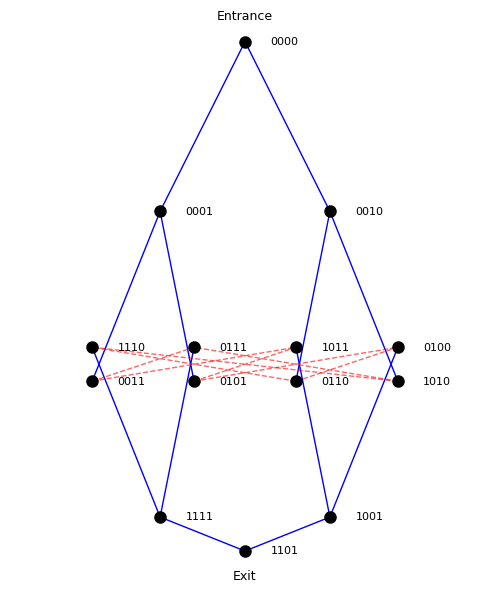

In [2]:
maze = HardWeldedTree(2)
edges = maze.get_edges()
fig = maze.draw()
plt.show()

In [3]:
print("Edges:")
for e in edges:
    print(e[0], '--->', e[1])

Edges:
1001 ---> 1101
1111 ---> 1101
0001 ---> 0011
0011 ---> 1011
0001 ---> 0101
0101 ---> 1011
0110 ---> 0100
1110 ---> 1111
1110 ---> 0110
0011 ---> 0111
0111 ---> 1111
0111 ---> 0011
1110 ---> 1010
0000 ---> 0010
0110 ---> 1110
1010 ---> 1110
1011 ---> 0011
0111 ---> 1010
1011 ---> 0101
1011 ---> 1001
0101 ---> 0100
0100 ---> 0101
0100 ---> 1001
0100 ---> 0110
1010 ---> 0111
0010 ---> 0110
0010 ---> 1010
0000 ---> 0001


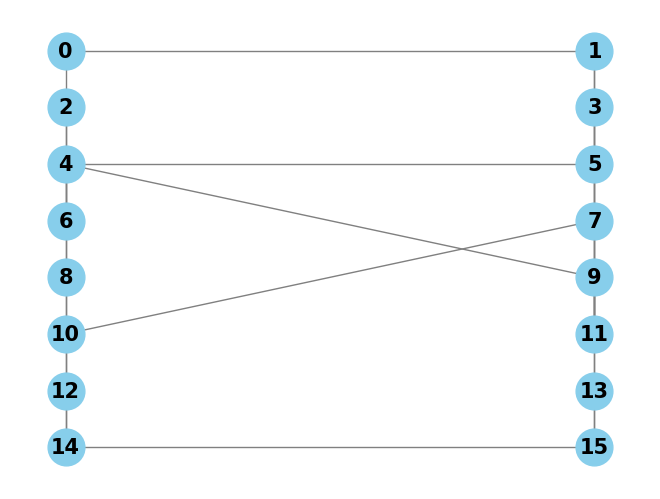

None

In [4]:
# Use your existing graph analysis
G_tree = StaticGraph(edges)
display(G_tree.draw())

Edges: {('1001', '1101'), ('0001', '0011'), ('0111', '1010'), ('0101', '1011'), ('0110', '0100'), ('0000', '0010'), ('1110', '1111')}


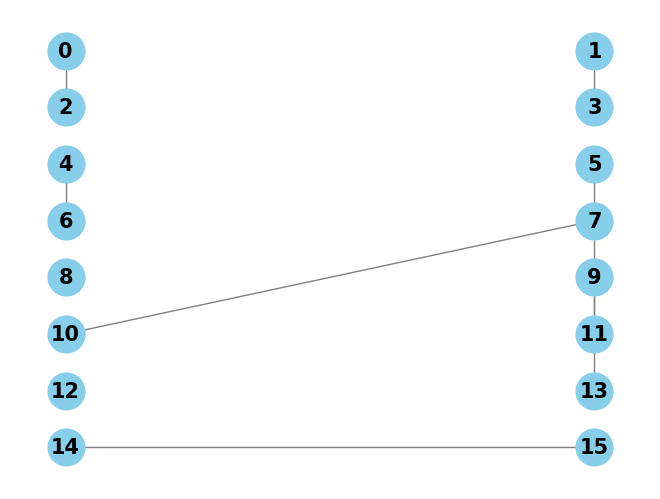

None

Simplified circuit: 


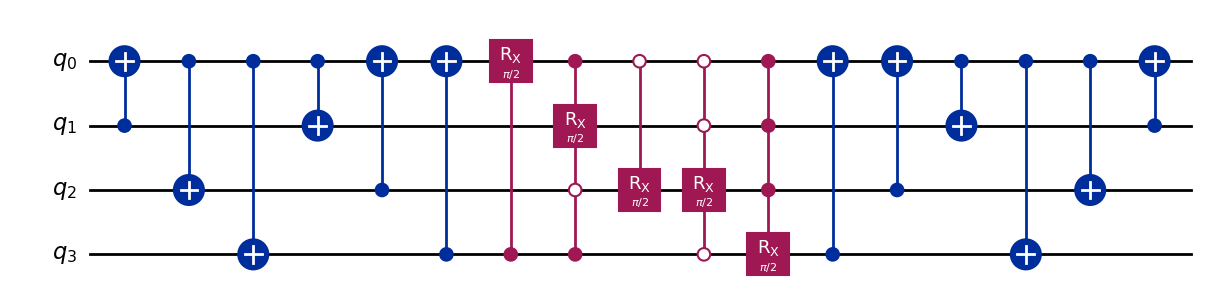

Edges: {('0100', '1001'), ('1111', '1101'), ('1110', '0110'), ('0011', '1011'), ('0001', '0101'), ('1010', '0111')}


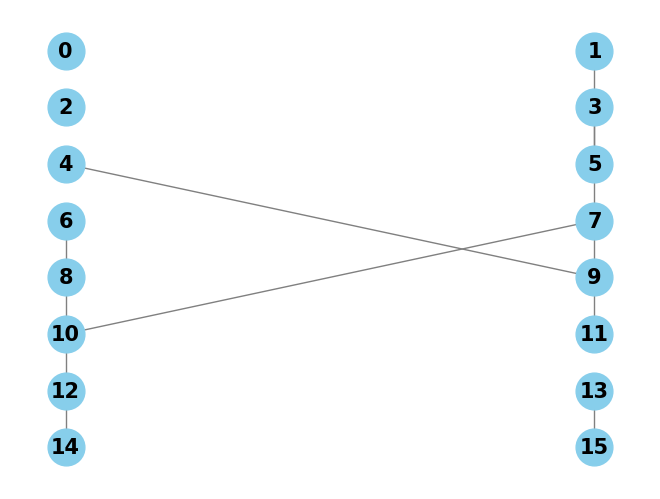

None

Simplified circuit: 


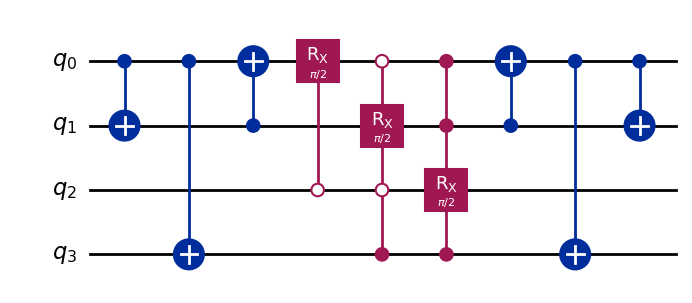

Edges: {('0100', '0110'), ('0011', '0111'), ('1011', '0101'), ('1110', '1010'), ('0000', '0001')}


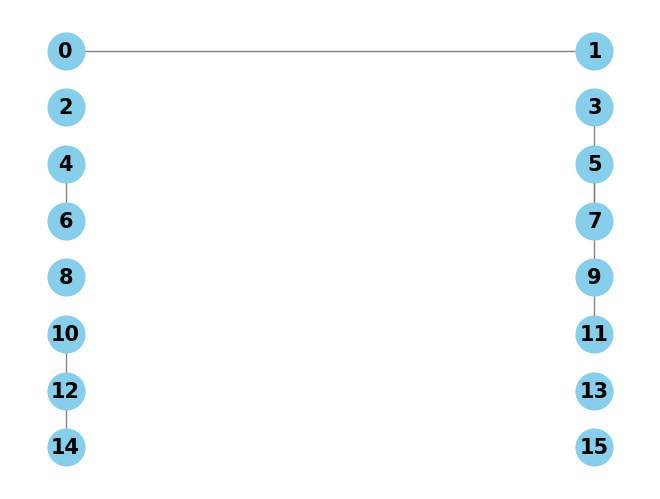

None

Simplified circuit: 


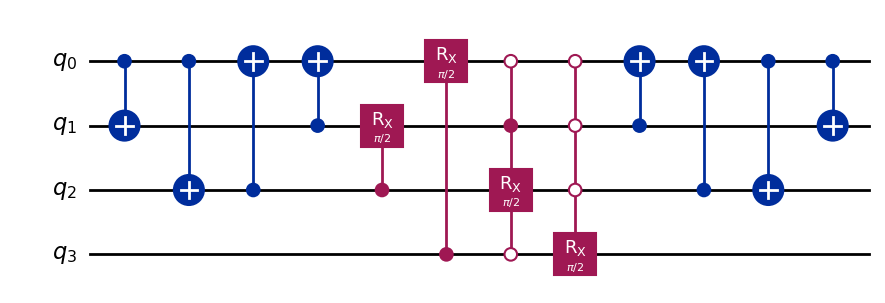

Edges: {('0101', '0100'), ('0110', '1110'), ('1011', '0011'), ('0111', '1111'), ('0010', '1010')}


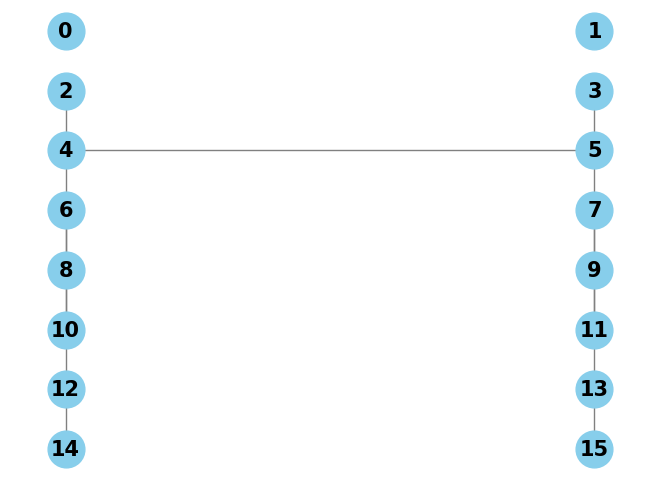

None

Simplified circuit: 


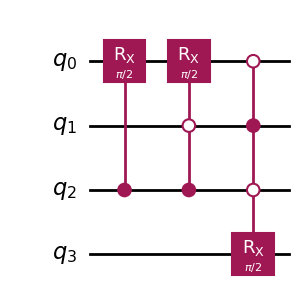

Edges: {('0100', '0101'), ('1010', '1110'), ('1011', '1001'), ('0010', '0110'), ('0111', '0011')}


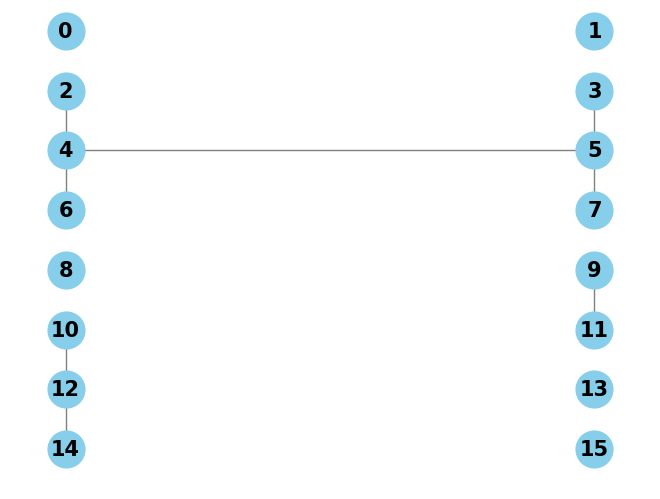

None

Simplified circuit: 


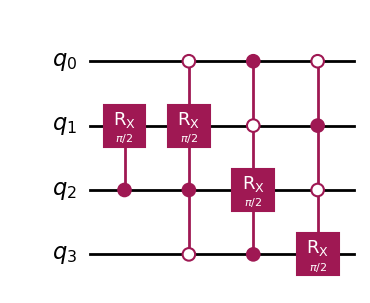

In [5]:

G = IntersectingEdgesGraph(edges)

big_qc = QuantumCircuit(G_tree.n_qubits)

for g in G.subgraphs:
    print(f'Edges: {g.edges}')
    display(g.draw())
    # print('Unsimplified circuit: ')
    # qc = g.get_qc(simplified=False)
    # display(qc.draw('mpl'))
    print('Simplified circuit: ')
    qc = g.get_qc(simplified=True)
    big_qc = big_qc.compose(qc)
    display(qc.draw('mpl'))
    

Full Circuit


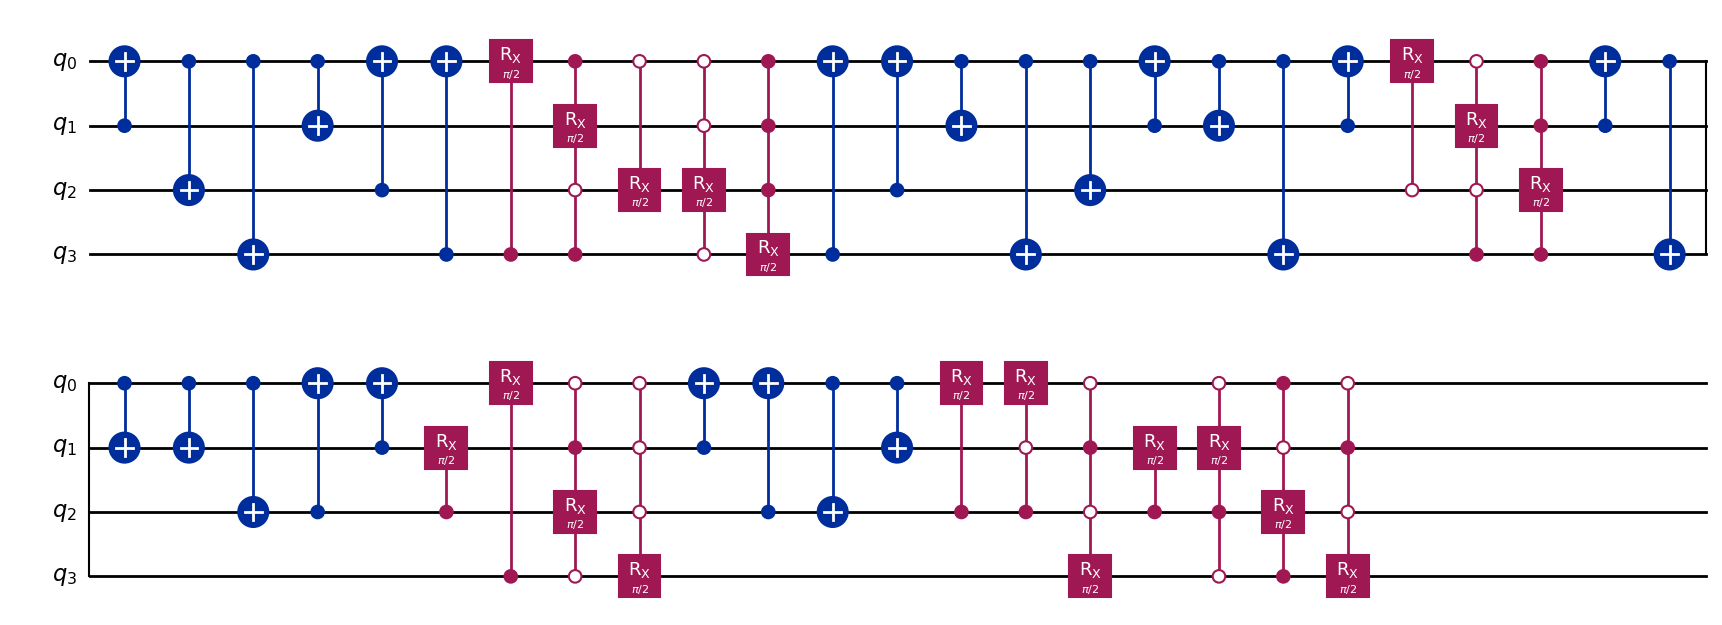

In [6]:
print('Full Circuit')
big_qc.draw('mpl')

In [7]:
from qiskit import transpile

transpiled_qc = transpile(
    big_qc,
    basis_gates=["cx", "u3"],
    optimization_level=3,
    seed_transpiler=12345
)

counts = transpiled_qc.count_ops()
print(f'Number of CX gates: {counts['cx']}')
print(f'Number of U3 gates: {counts['u3']}')

Number of CX gates: 262
Number of U3 gates: 219


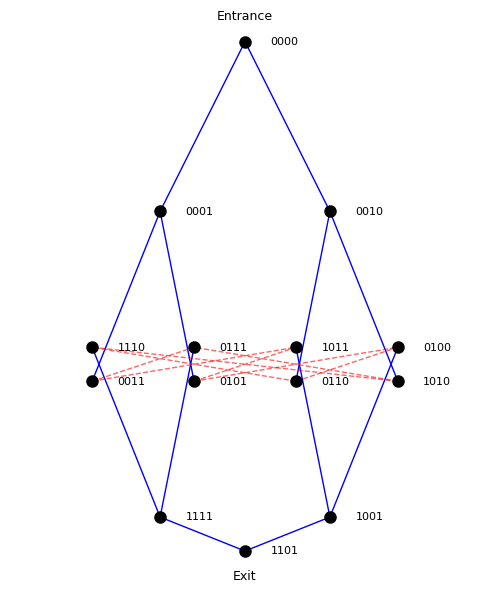

Edges:
1001 ---> 1101
1111 ---> 1101
0001 ---> 0011
0011 ---> 1011
0001 ---> 0101
0101 ---> 1011
0110 ---> 0100
1110 ---> 1111
1110 ---> 0110
0011 ---> 0111
0111 ---> 1111
0111 ---> 0011
1110 ---> 1010
0000 ---> 0010
0110 ---> 1110
1010 ---> 1110
1011 ---> 0011
0111 ---> 1010
1011 ---> 0101
1011 ---> 1001
0101 ---> 0100
0100 ---> 0101
0100 ---> 1001
0100 ---> 0110
1010 ---> 0111
0010 ---> 0110
0010 ---> 1010
0000 ---> 0001


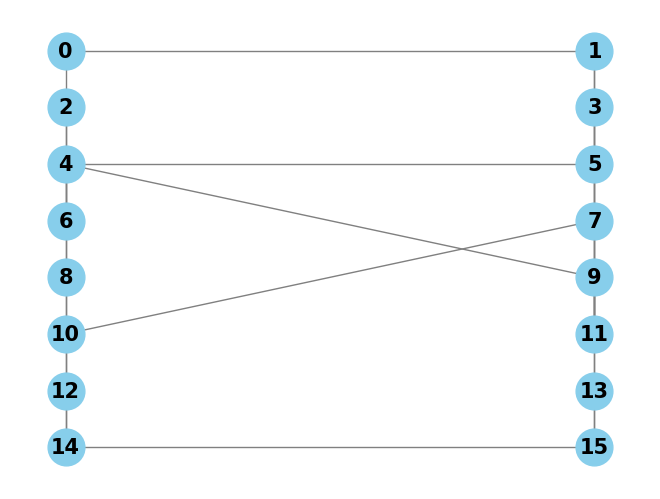

None

Edges: {('1001', '1101'), ('0001', '0011'), ('0111', '1010'), ('0101', '1011'), ('0110', '0100'), ('0000', '0010'), ('1110', '1111')}


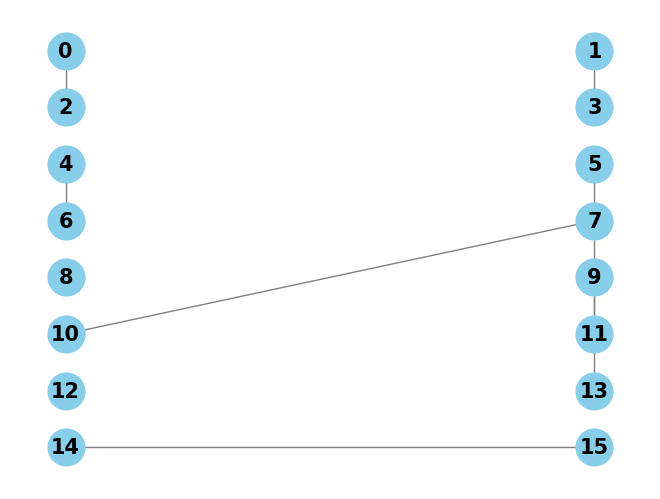

None

Simplified circuit: 


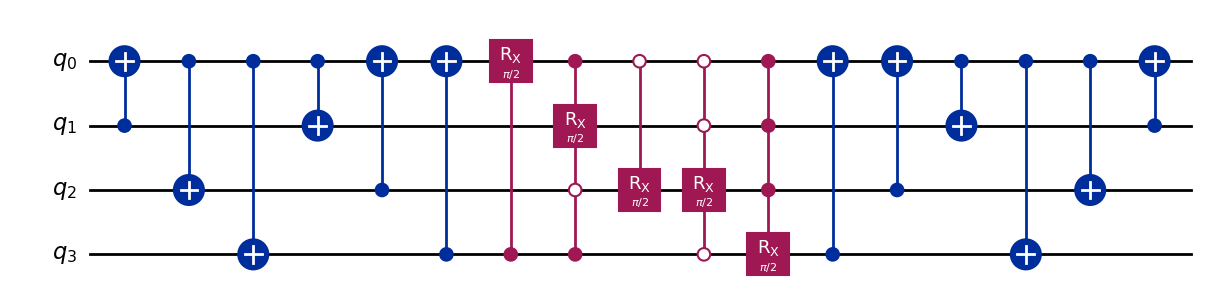

Edges: {('0100', '1001'), ('1111', '1101'), ('1110', '0110'), ('0011', '1011'), ('0001', '0101'), ('1010', '0111')}


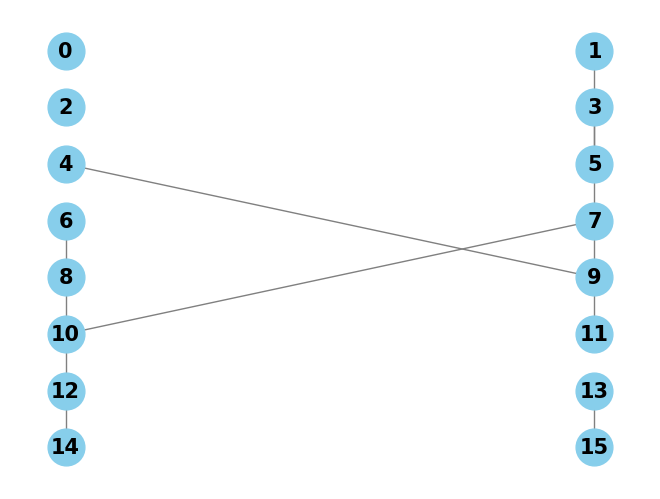

None

Simplified circuit: 


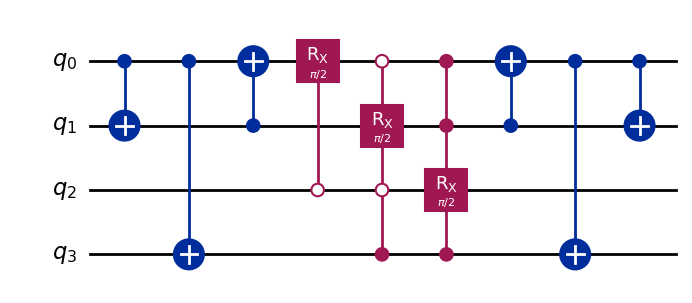

Edges: {('0100', '0110'), ('0011', '0111'), ('1011', '0101'), ('1110', '1010'), ('0000', '0001')}


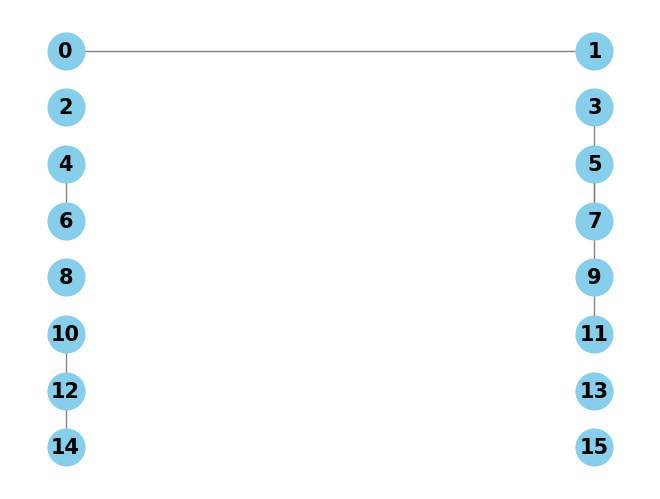

None

Simplified circuit: 


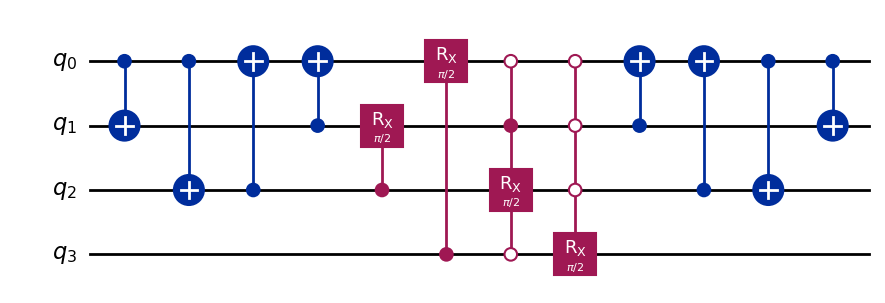

Edges: {('0101', '0100'), ('0110', '1110'), ('1011', '0011'), ('0111', '1111'), ('0010', '1010')}


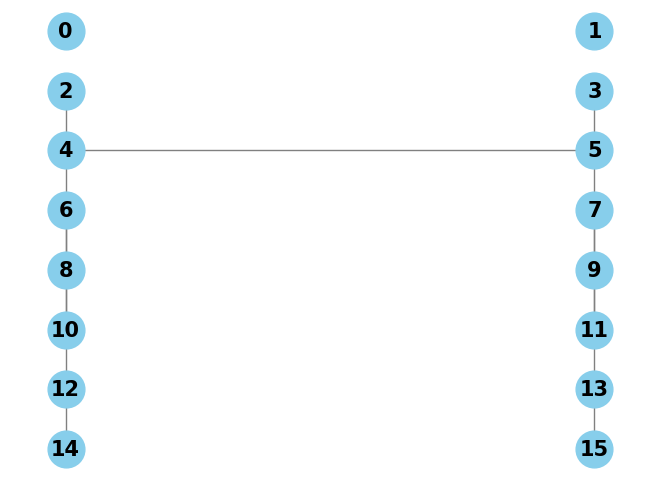

None

Simplified circuit: 


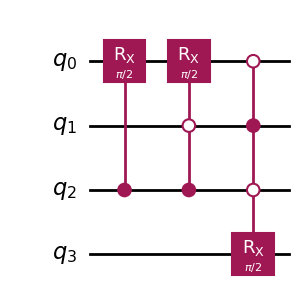

Edges: {('0100', '0101'), ('1010', '1110'), ('1011', '1001'), ('0010', '0110'), ('0111', '0011')}


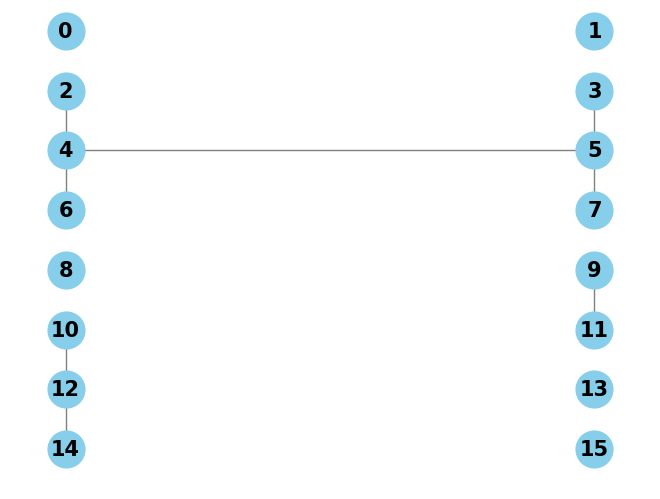

None

Simplified circuit: 


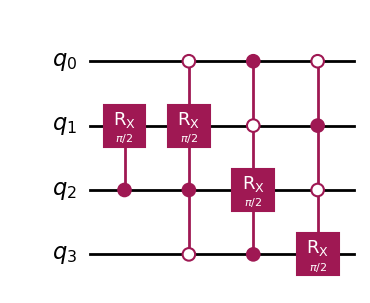

Full Circuit
Number of CX gates: 262
Number of U3 gates: 219


In [8]:
def analyze_welded_tree(height: int):
    """Analyze the Hard Welded Tree and generate quantum circuits."""
    # Create and analyze tree
    maze = HardWeldedTree(height)
    edges = maze.get_edges()
    
    # Display tree structure
    fig = maze.draw()
    plt.show()
    
    # Print edges
    print("Edges:")
    for e in edges:
        print(e[0], '--->', e[1])
    
    # Graph analysis
    G_tree = StaticGraph(edges)
    display(G_tree.draw())
    
    # Generate quantum circuits
    G = IntersectingEdgesGraph(edges)
    big_qc = QuantumCircuit(G_tree.n_qubits)
    
    # Process each subgraph
    for g in G.subgraphs:
        print(f'Edges: {g.edges}')
        display(g.draw())
        print('Simplified circuit: ')
        qc = g.get_qc(simplified=True)
        big_qc = big_qc.compose(qc)
        display(qc.draw('mpl'))
    
    # Show and analyze final circuit
    print('Full Circuit')
    big_qc.draw('mpl')
    
    # Transpile circuit
    transpiled_qc = transpile(
        big_qc,
        basis_gates=["cx", "u3"],
        optimization_level=3,
        seed_transpiler=12345
    )
    
    # Display gate counts
    counts = transpiled_qc.count_ops()
    print(f'Number of CX gates: {counts["cx"]}')
    print(f'Number of U3 gates: {counts["u3"]}')
    
    return big_qc, transpiled_qc

# Run analysis
big_qc, transpiled_qc = analyze_welded_tree(2)

{0: '0000', 1: '0001', 2: '0010', 3: '0011', 4: '0101', 5: '0110', 6: '1010', 8: '0111', 9: '1011', 10: '0100', 7: '1110', 11: '1111', 12: '1001', 13: '1101'}


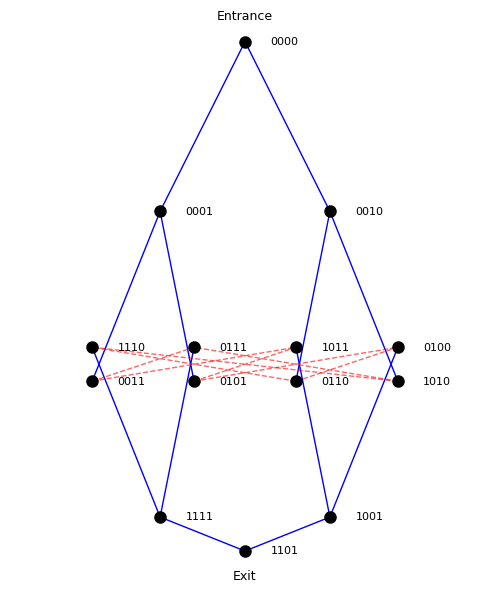

Edges:
1001 ---> 1101
1111 ---> 1101
0001 ---> 0011
0011 ---> 1011
0001 ---> 0101
0101 ---> 1011
0110 ---> 0100
1110 ---> 1111
1110 ---> 0110
0011 ---> 0111
0111 ---> 1111
0111 ---> 0011
1110 ---> 1010
0000 ---> 0010
0110 ---> 1110
1010 ---> 1110
1011 ---> 0011
0111 ---> 1010
1011 ---> 0101
1011 ---> 1001
0101 ---> 0100
0100 ---> 0101
0100 ---> 1001
0100 ---> 0110
1010 ---> 0111
0010 ---> 0110
0010 ---> 1010
0000 ---> 0001


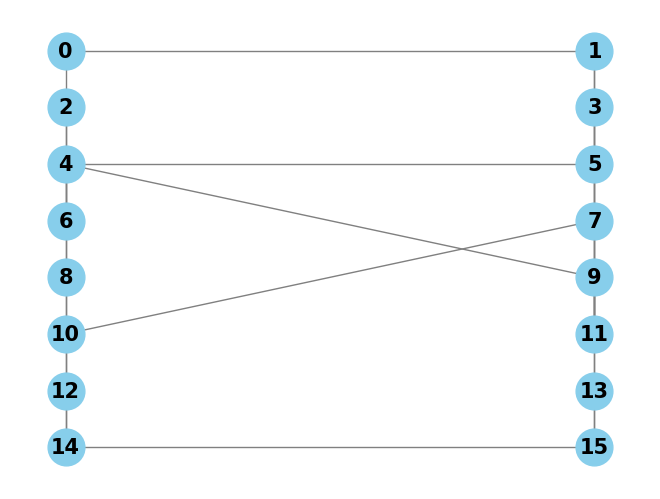

None

Edges: {('1001', '1101'), ('0001', '0011'), ('0111', '1010'), ('0101', '1011'), ('0110', '0100'), ('0000', '0010'), ('1110', '1111')}


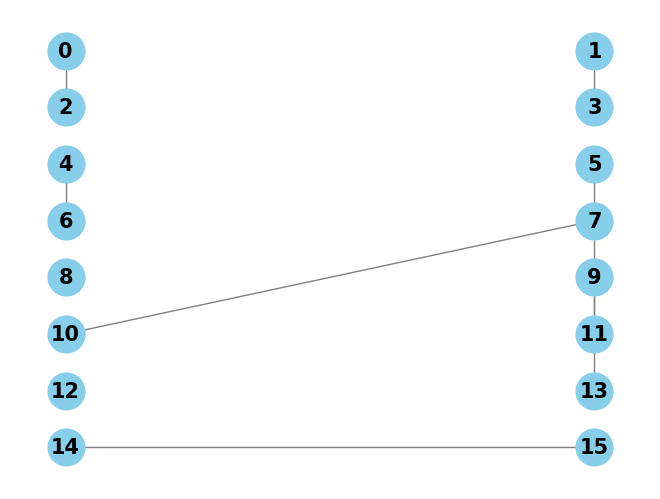

None

Simplified circuit: 


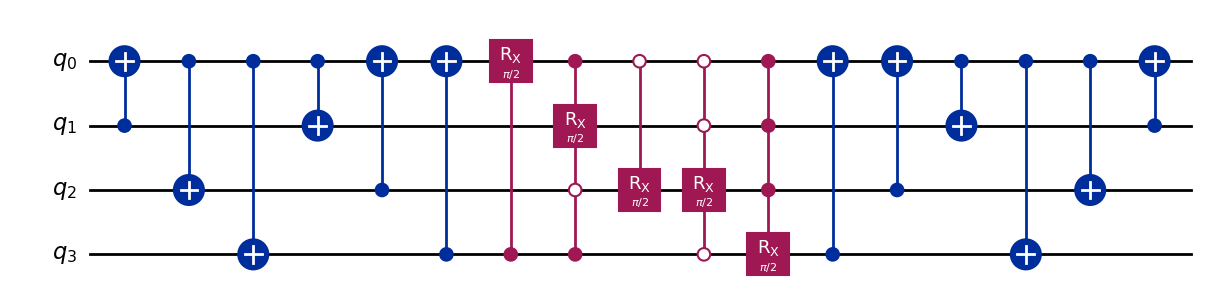

Edges: {('0100', '1001'), ('1111', '1101'), ('1110', '0110'), ('0011', '1011'), ('0001', '0101'), ('1010', '0111')}


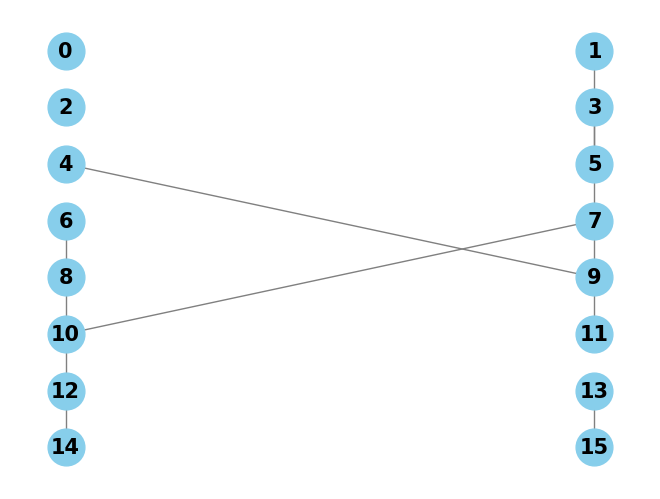

None

Simplified circuit: 


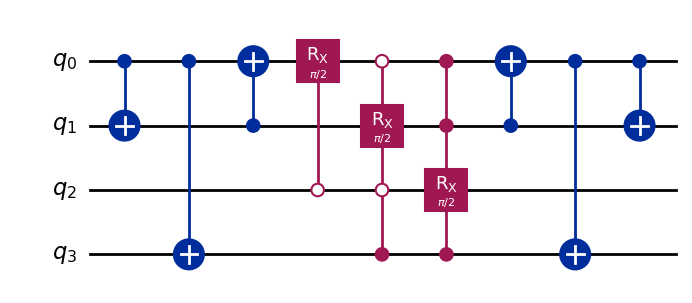

Edges: {('0100', '0110'), ('0011', '0111'), ('1011', '0101'), ('1110', '1010'), ('0000', '0001')}


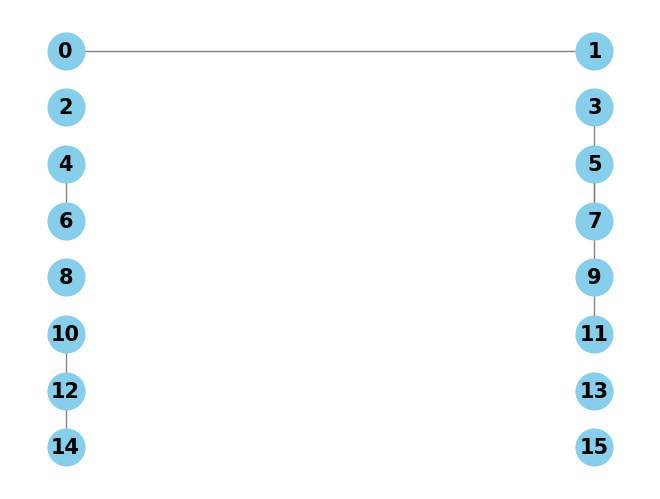

None

Simplified circuit: 


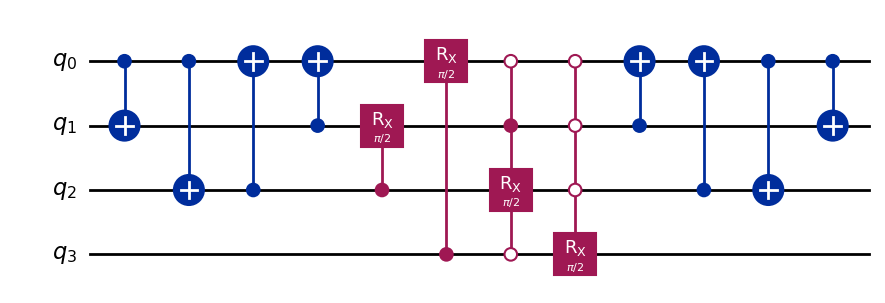

Edges: {('0101', '0100'), ('0110', '1110'), ('1011', '0011'), ('0111', '1111'), ('0010', '1010')}


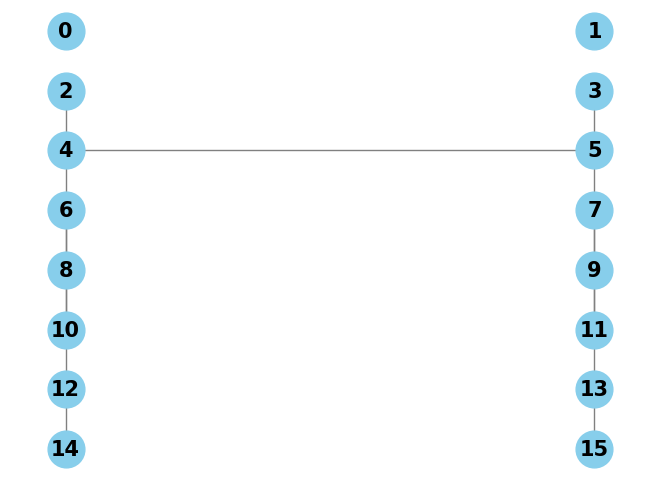

None

Simplified circuit: 


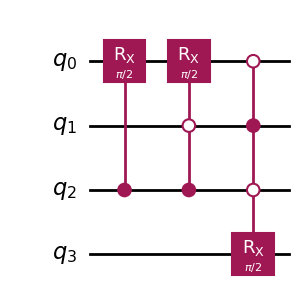

Edges: {('0100', '0101'), ('1010', '1110'), ('1011', '1001'), ('0010', '0110'), ('0111', '0011')}


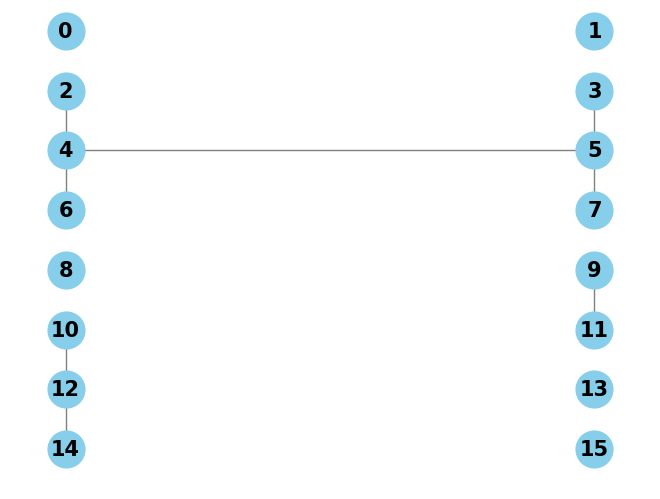

None

Simplified circuit: 


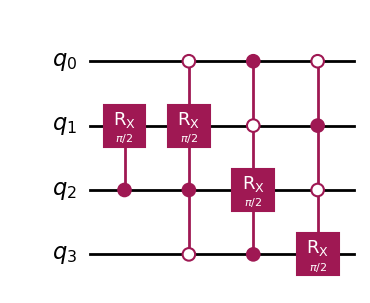

Full Circuit
Number of CX gates: 262
Number of U3 gates: 219


In [9]:
import sys
sys.path.append(f"./../")
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from src.graphs import StaticGraph, IntersectingEdgesGraph
from src.bwt import HardWeldedTree, OptimalLabeler

def analyze_welded_tree(height: int = 2):
    # Create temporary tree to get edge structure
    temp_tree = HardWeldedTree(height)
    edges = temp_tree._create_edge_list()
    
    # Get optimal labeling
    labeler = OptimalLabeler(temp_tree.num_vertices)
    vertex_labels = labeler.optimize_labels(edges)
    print(vertex_labels)
    is_valid, stats = labeler.verify_labeling(edges)
    
    if not is_valid:
        raise ValueError("Invalid labeling generated")
    
    # Create final tree with optimal labels
    maze = HardWeldedTree(height, fixed_labels=vertex_labels)
    edges = maze.get_edges()
    
    # Display and analyze
    fig = maze.draw()
    plt.show()
    
    print("Edges:")
    for e in edges:
        print(e[0], '--->', e[1])
    
    G_tree = StaticGraph(edges)
    display(G_tree.draw())
    
    G = IntersectingEdgesGraph(edges)
    big_qc = QuantumCircuit(G_tree.n_qubits)
    
    for g in G.subgraphs:
        print(f'Edges: {g.edges}')
        display(g.draw())
        print('Simplified circuit: ')
        qc = g.get_qc(simplified=True)
        big_qc = big_qc.compose(qc)
        display(qc.draw('mpl'))
    
    print('Full Circuit')
    big_qc.draw('mpl')
    
    transpiled_qc = transpile(
        big_qc,
        basis_gates=["cx", "u3"],
        optimization_level=3,
        seed_transpiler=12345
    )
    
    counts = transpiled_qc.count_ops()
    print(f'Number of CX gates: {counts["cx"]}')
    print(f'Number of U3 gates: {counts["u3"]}')
    
    return big_qc, transpiled_qc, maze

if __name__ == "__main__":
    big_qc, transpiled_qc, maze = analyze_welded_tree(2)